In [1]:
from pdf_edges import extract_pdf_edges
from ifc_edges import extract_ifc_plan_edges 
from visualization_extraction import visualize_segments

Successfully extracted 39564 vector segments.


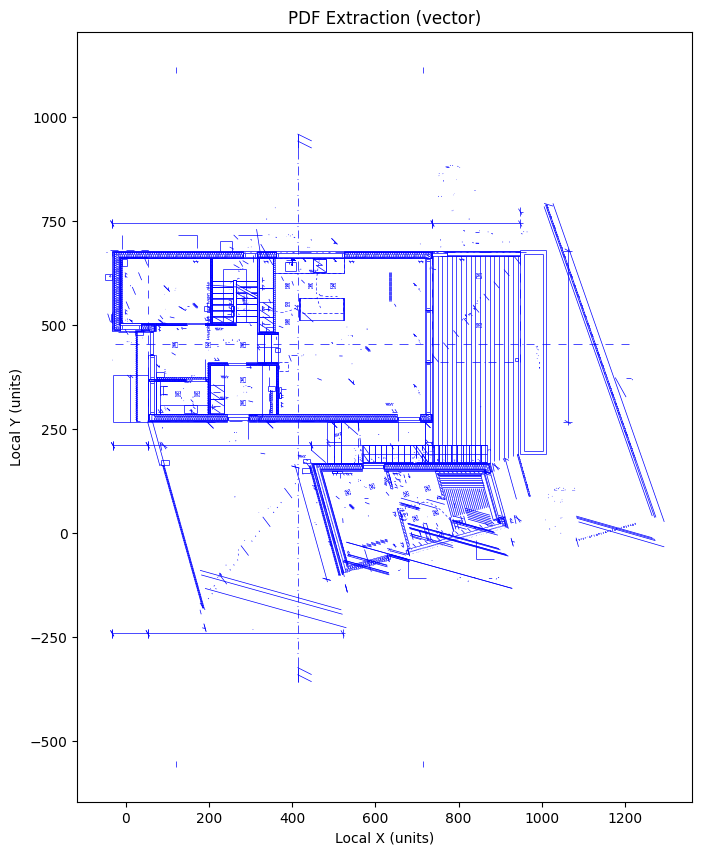

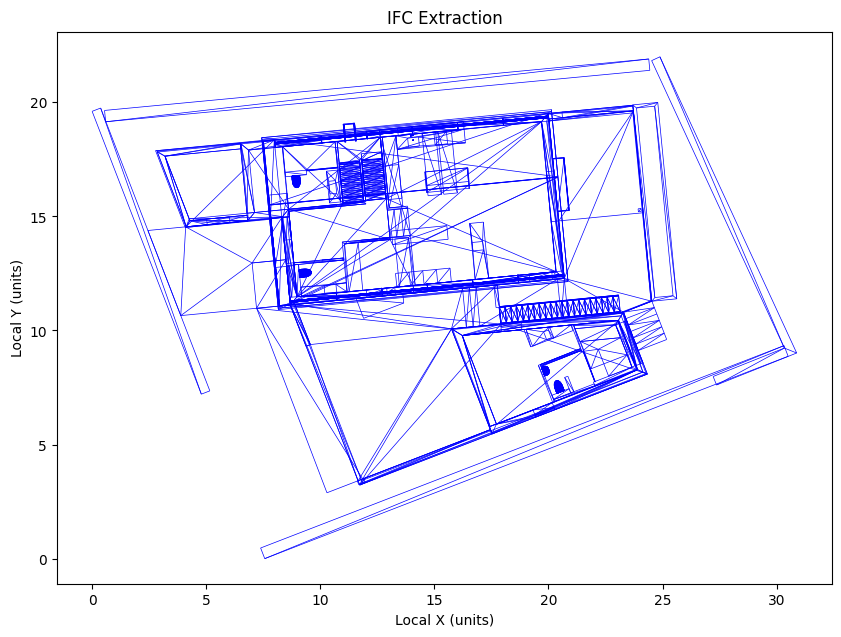

In [3]:
pdf_segs, pdf_meta = extract_pdf_edges("/home/chidepnek/RoboAI/BIM/BOMBIM/BIM2/backend/src/reg_v2/SÃ_HKÃ_TASO 1.KRS.pdf")
visualize_segments(pdf_segs, f"PDF Extraction ({pdf_meta.method})")

ifc_segs, ifc_meta = extract_ifc_plan_edges("/home/chidepnek/RoboAI/BIM/BOMBIM/BIM2/backend/src/reg_v2/Asikainen.ifc")
visualize_segments(ifc_segs, "IFC Extraction")

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from align_hvac import run_alignment_pipeline

In [13]:
import json

with open("alignment_results.json", "r") as f:
    res=json.load(f)

final_params = (res['scale'], res['rotation'], res['tx'], res['ty'])

(34.19282667388598, 175.0, 0.0, 0.0)


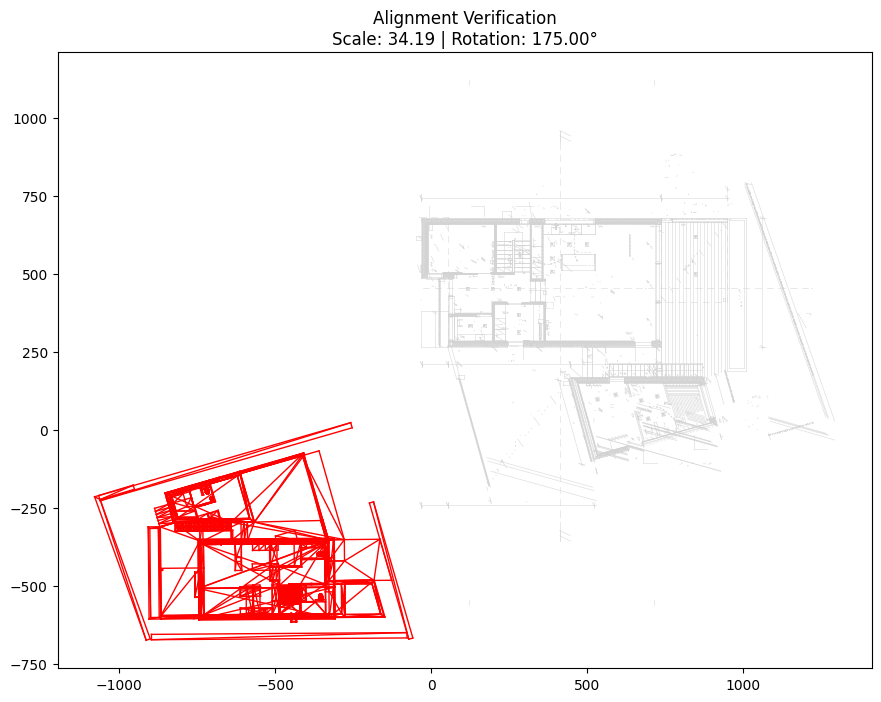

In [ ]:
def verify_alignment_visually(ifc_segs, pdf_segs, params):
    """
    Overlays the IFC segments (in Red) onto the PDF segments (in Gray).
    """
    s, theta, tx, ty = params
    rad = np.radians(theta)
    
    # Define the Rotation Matrix
    R = np.array([
        [np.cos(rad), -np.sin(rad)],
        [np.sin(rad),  np.cos(rad)]
    ])

    plt.figure(figsize=(12, 8))
    
    # 1. Plot PDF in the background (Gray)
    for x1, y1, x2, y2 in pdf_segs:
        plt.plot([x1, x2], [y1, y2], color='lightgray', linewidth=0.5, alpha=0.7)

    # 2. Transform and Plot IFC in the foreground (Red)
    for x1, y1, x2, y2 in ifc_segs:
        # Apply the scale, rotation, and translation
        p1 = s * (R @ np.array([x1, y1])) + np.array([tx, ty])
        p2 = s * (R @ np.array([x2, y2])) + np.array([tx, ty])
        
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], color='red', linewidth=1.0)

    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(f"Alignment Verification\nScale: {s:.2f} | Rotation: {theta:.2f}°")
    plt.show()

# Run it with your results:
print(final_params)
verify_alignment_visually(ifc_segs, pdf_segs, final_params)

In [ ]:
import json

with open("alignment_results.json", "r") as f:
    res=json.load(f)

final_params = (res['scale'], res['rotation'], res['tx'], res['ty'])

print(final_params)
verify_alignment_visually(ifc_segs, pdf_segs, final_params)